# Predicted tumor ROI → GLCM-96 → PCA-50
Unexecuted notebook: run cells in order in a fresh kernel. Existing datasets, masks, notebooks and models are read-only. No U-Net/SVM/KNN training is performed. Only StandardScaler and PCA are fitted, on train data only.

Preprocessed .npy MRI → trained U-Net → probability ≥ 0.5 → conservative mask filtering → MRI × mask → bounding box → crop → 96 GLCM features → scaler → 50 PCA components.

Generated CSVs, issue reports and deployment artifacts will be saved in `Features_newPipeline` when you run the notebook. No masks/ROI images are saved. No artifacts have been fitted or generated during notebook creation.


## 1. Imports


In [1]:
import json, re, hashlib, platform
from pathlib import Path
from collections import Counter
from time import perf_counter
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
from tqdm.auto import tqdm
from skimage.feature import graycomatrix, graycoprops
import skimage, sklearn, joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


## 2. Configuration / paths


In [2]:
PROJECT_DIR = Path(r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project")
DATASET_DIR = PROJECT_DIR / "DATASET" / "Preprocessed_segmented1"
MODEL_PATH = Path(r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras")
OUTPUT_DIR = PROJECT_DIR / "Features_newPipeline"
IMG_SIZE = 256
THRESHOLD = 0.5
MIN_COMPONENT_AREA = 2
N_COMPONENTS = 50
SEED = 42
PREVIEW_PER_SPLIT = 3
CLASS_CODE_MAP = {"gl": "glioma", "me": "meningioma", "pi": "pituitary"}
CLASS_NAMES = set(CLASS_CODE_MAP.values())
FILE_PATTERN = re.compile(r"^brisc2025_(train|test)_\d+_(gl|me|pi)_.+$", re.IGNORECASE)
print("Dataset:", DATASET_DIR)
print("Existing U-Net:", MODEL_PATH)
print("All generated outputs:", OUTPUT_DIR)


Dataset: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented1
Existing U-Net: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras
All generated outputs: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline


## 3. Dataset inspection
Read-only inspection during creation found `train/images` (3,933 .npy files), `test/images` (860), and respective `masks` folders with matching counts. Image directories are flat; class codes are in BRISC filenames (`gl`, `me`, `pi`). The cell below rediscovers structure, formats, shapes, dtypes, counts, and labels at runtime. Masks are inventoried by filename only, never loaded for ROI generation.

Class folders are also supported. Unknown labels/layouts are reported rather than guessed. Duplicate IDs and conflicting filename/folder labels are rejected. File inspection cannot establish patient-level independence or the saved model's training history.


In [3]:
def find_directory(parent, name):
    if not parent.is_dir():
        raise FileNotFoundError(parent)
    matches = [p for p in parent.iterdir() if p.is_dir() and p.name.lower() == name]
    if len(matches) != 1:
        raise ValueError(f"Expected one {name} folder under {parent}; found {matches}")
    return matches[0]


def load_mri(path):
    if path.suffix.lower() != ".npy":
        raise ValueError(f"Expected preprocessed .npy MRI: {path}")
    image = np.load(path, allow_pickle=False)
    if image.shape == (IMG_SIZE, IMG_SIZE, 1):
        image = image[..., 0]
    if image.shape != (IMG_SIZE, IMG_SIZE) or image.dtype != np.float32:
        raise ValueError(f"Expected float32 (256,256); got {image.shape}/{image.dtype}: {path}")
    if not np.isfinite(image).all():
        raise ValueError(f"Non-finite MRI: {path}")
    mean, std = float(image.mean()), float(image.std())
    if abs(mean) > 1e-4 or not (abs(std - 1) < 1e-4 or std < 1e-8):
        raise ValueError(f"Expected existing Z-score normalization; mean={mean}, std={std}: {path}")
    return image  # Never normalize, resize, blur, or divide by 255 again.


def detect_label(path, image_root, split):
    relative = path.relative_to(image_root)
    folder_label = relative.parts[0] if len(relative.parts) > 1 else None
    match = FILE_PATTERN.fullmatch(path.stem)
    filename_label = None
    if match:
        if match.group(1).lower() != split:
            raise ValueError(f"Filename split disagrees with directory: {path}")
        filename_label = CLASS_CODE_MAP[match.group(2).lower()]
    if folder_label is not None:
        if folder_label not in CLASS_NAMES:
            raise ValueError(f"Unknown class folder: {folder_label}")
        if filename_label is not None and folder_label != filename_label:
            raise ValueError(f"Filename/folder class mismatch: {path}")
        return folder_label
    if filename_label is None:
        raise ValueError(f"Cannot determine class from flat filename: {path.name}")
    return filename_label


def inspect_split(split):
    split_path = find_directory(DATASET_DIR, split)
    image_root = find_directory(split_path, "images")
    mask_dirs = [p for p in split_path.iterdir() if p.is_dir() and p.name.lower() == "masks"]
    masks = [p for folder in mask_dirs for p in folder.rglob("*") if p.is_file()]
    files = sorted(p for p in image_root.rglob("*") if p.is_file())
    images = [p for p in files if p.suffix.lower() == ".npy"]
    print(f"\n{split.upper()}: {split_path}; image path: {image_root}")
    print("Formats:", dict(Counter(p.suffix.lower() for p in files)))
    print("Subfolders:", [str(p.relative_to(image_root)) for p in image_root.rglob("*") if p.is_dir()])
    print("Image count:", len(images), "Masks exist:", bool(mask_dirs), "Mask count:", len(masks))
    print("Matching image/mask stems:", len({p.stem for p in images} & {p.stem for p in masks}))
    if not images:
        raise ValueError(f"No .npy MRI images: {image_root}")
    records, issues, properties = [], [], Counter()
    for path in tqdm(images, desc=f"Inspect {split}"):
        identifier = path.relative_to(image_root).as_posix()
        try:
            label = detect_label(path, image_root, split)
            image = load_mri(path)
            properties[(str(image.shape), str(image.dtype))] += 1
            records.append({"filename": identifier, "class": label, "path": path, "split": split})
        except Exception as error:
            issues.append({"image_name": identifier, "split": split,
                           "error_type": "InvalidImageOrLabel", "error_message": str(error)})
    manifest = pd.DataFrame(records, columns=["filename", "class", "path", "split"])
    if manifest["filename"].duplicated().any():
        raise ValueError(f"Duplicate identifiers in {split}")
    print("Dimensions/dtypes:", dict(properties))
    print("Classes:", manifest["class"].value_counts().to_dict(), "Invalid inputs:", len(issues))
    if issues:
        display(pd.DataFrame(issues))
    return manifest, issues, len(images)


train_manifest, train_inspection_issues, train_input_count = inspect_split("train")
test_manifest, test_inspection_issues, test_input_count = inspect_split("test")
if train_manifest.empty or test_manifest.empty:
    raise ValueError("No valid train or test images; review inspection errors")
if set(train_manifest["path"]) & set(test_manifest["path"]):
    raise ValueError("Train/test paths overlap")
if set(train_manifest["filename"]) & set(test_manifest["filename"]):
    raise ValueError("Train/test IDs overlap; investigate")
if not set(test_manifest["class"]).issubset(set(train_manifest["class"])):
    raise ValueError("Test class absent from train")



TRAIN: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented1\train; image path: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented1\train\images
Formats: {'.npy': 3933}
Subfolders: []
Image count: 3933 Masks exist: True Mask count: 3933
Matching image/mask stems: 3933


Inspect train:   0%|          | 0/3933 [00:00<?, ?it/s]

Dimensions/dtypes: {('(256, 256)', 'float32'): 3933}
Classes: {'pituitary': 1457, 'meningioma': 1329, 'glioma': 1147} Invalid inputs: 0

TEST: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented1\test; image path: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented1\test\images
Formats: {'.npy': 860}
Subfolders: []
Image count: 860 Masks exist: True Mask count: 860
Matching image/mask stems: 860


Inspect test:   0%|          | 0/860 [00:00<?, ?it/s]

Dimensions/dtypes: {('(256, 256)', 'float32'): 860}
Classes: {'meningioma': 306, 'pituitary': 300, 'glioma': 254} Invalid inputs: 0


## 4. Load existing U-Net
`Training_U-Net.ipynb` uses a Colab training archive and internal validation split. That code alone does not establish the provenance of the local .keras file. Confirm that actual test images were not used for model training/selection. Existing train images may have trained U-Net; consider upstream training when interpreting classifier cross-validation.

No model training is attempted if the file is missing. Enable deterministic TensorFlow operations and reuse an inference graph for one image at a time.


In [4]:
if not MODEL_PATH.is_file():
    raise FileNotFoundError(f"Existing U-Net unavailable: {MODEL_PATH}; no retraining attempted")
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
if tuple(model.input_shape[1:]) != (IMG_SIZE, IMG_SIZE, 1):
    raise ValueError(f"Unexpected U-Net input: {model.input_shape}")
if tuple(model.output_shape[1:]) != (IMG_SIZE, IMG_SIZE, 1):
    raise ValueError(f"Unexpected U-Net output: {model.output_shape}")
print("Model input/output:", model.input_shape, model.output_shape)
print("Visible GPUs:", tf.config.get_visible_devices("GPU"))


Model input/output: (None, 256, 256, 1) (None, 256, 256, 1)
Visible GPUs: []


## 5. Segmentation functions


In [5]:
@tf.function(input_signature=[tf.TensorSpec((1, IMG_SIZE, IMG_SIZE, 1), tf.float32)])
def infer_one(tensor):
    return model(tensor, training=False)


def predict_mask(image):
    output = infer_one(tf.convert_to_tensor(image[None, ..., None])).numpy()
    if output.shape != (1, IMG_SIZE, IMG_SIZE, 1):
        raise ValueError(f"Invalid prediction shape: {output.shape}")
    probability = output[0, ..., 0]
    if not np.isfinite(probability).all() or np.any((probability < 0) | (probability > 1)):
        raise ValueError("Expected finite sigmoid probabilities in [0,1]")
    return probability, (probability >= THRESHOLD).astype(np.uint8)


## 6. Mask post-processing
Reuse the current ROI notebook's conservative rule: 8-connected components, retaining **all components of at least two pixels**. Only isolated single pixels are removed. No largest-component selection, erosion, closing or hole filling. No MRI preprocessing. Masks remain in memory.


In [6]:
def postprocess_mask(raw_mask):
    _, labels, stats, _ = cv2.connectedComponentsWithStats(raw_mask, connectivity=8)
    keep = (stats[:, cv2.CC_STAT_AREA] >= MIN_COMPONENT_AREA).astype(np.uint8)
    keep[0] = 0
    return keep[labels]


## 7. ROI / bounding box
Find the bounding box from mask pixels, **not `roi > 0`**, because tumor Z-scores can be negative or zero. Enclose all retained components and keep zero background inside the crop. Empty masks are logged/skipped, never assigned invented features. Every omitted image must appear in the issue report.


In [7]:
class EmptyMaskError(ValueError):
    pass


def crop_roi(image, mask):
    ys, xs = np.where(mask != 0)
    if not len(xs):
        raise EmptyMaskError("No foreground after thresholding/component filtering")
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    x0, x1 = int(xs.min()), int(xs.max()) + 1
    if not (0 <= y0 < y1 <= IMG_SIZE and 0 <= x0 < x1 <= IMG_SIZE):
        raise ValueError("Invalid bounding box")
    roi = image * mask
    foreground = mask.astype(bool)
    if roi.dtype != np.float32 or roi.shape != image.shape or not np.isfinite(roi).all():
        raise ValueError("Invalid ROI")
    if np.any(roi[~foreground] != 0) or not np.array_equal(roi[foreground], image[foreground]):
        raise ValueError("ROI intensities/background changed")
    return roi, roi[y0:y1, x0:x1], (x0, y0, x1, y1)


## 8. Visualization helper
Sample execution follows the GLCM functions, so the quantized crop is also visible.


In [8]:
def show_stages(result, title):
    fig, axes = plt.subplots(1, 7, figsize=(23, 4))
    panels = [(result["image"], "Original MRI"), (result["probability"], "U-Net probability"),
              (result["raw_mask"], "Predicted mask"), (result["mask"], "Processed mask"),
              (result["image"], "Bounding box"), (result["crop"], "Cropped masked ROI"),
              (result["quantized"], "GLCM levels 0..31")]
    for ax, (array, label) in zip(axes, panels):
        ax.imshow(array, cmap="gray")
        ax.set_title(label)
        ax.axis("off")
    x0, y0, x1, y1 = result["bbox"]
    axes[4].add_patch(Rectangle((x0-0.5, y0-0.5), x1-x0, y1-y0, fill=False, edgecolor="red"))
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## 9. GLCM configuration and methodology
Primary reference: `Feauture_Extraction_1.ipynb`, setup/extraction sections.

| Setting | Value |
|---|---|
| Distances | 1, 2, 3, 4 pixels |
| Angles | 0°, 45°, 90°, 135° (4 angles) |
| Gray levels | 32 |
| Symmetric | True |
| Normalized GLCM | True |
| Feature order | Property, distance, angle (reference order) |
| Quantization | Floating crop min-max to [0,31], clip, floor, uint8 |

| Property | Features |
|---|---|
| contrast | 16 |
| dissimilarity | 16 |
| homogeneity | 16 |
| energy | 16 |
| correlation | 16 |
| ASM | 16 |
| **Total** | **6 properties × 4 distances × 4 angles = 96** |

**Necessary changes from the reference:** Crop using the predicted mask rather than positive MRI values. Do not cast float Z-scores to uint8 before normalization, which truncates/wraps intensities. Scale the floating crop first, then quantize. Constant crops map to zero. This conversion is solely for GLCM, never fed into U-Net.

Like the reference, GLCM counts all pairs in the rectangular masked crop, including background pairs; this is not foreground-pair-only GLCM. A crop with no pixel pairs for any requested offset is reported/skipped instead of fabricating statistics. Corrected cropping/quantization changes feature distributions, so old scaler/PCA/classifier artifacts cannot be mixed with this pipeline.


In [9]:
GLCM_DISTANCES = [1, 2, 3, 4]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
ANGLE_NAMES = ["0", "45", "90", "135"]
GLCM_LEVELS = 32
GLCM_PROPERTIES = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]
FEATURE_NAMES = [f"{prop}_d{distance}_a{angle}" for prop in GLCM_PROPERTIES
                 for distance in GLCM_DISTANCES for angle in ANGLE_NAMES]
assert len(FEATURE_NAMES) == len(set(FEATURE_NAMES)) == 96
print("GLCM features:", len(FEATURE_NAMES))


GLCM features: 96


## 10. GLCM extraction functions and sample visualization


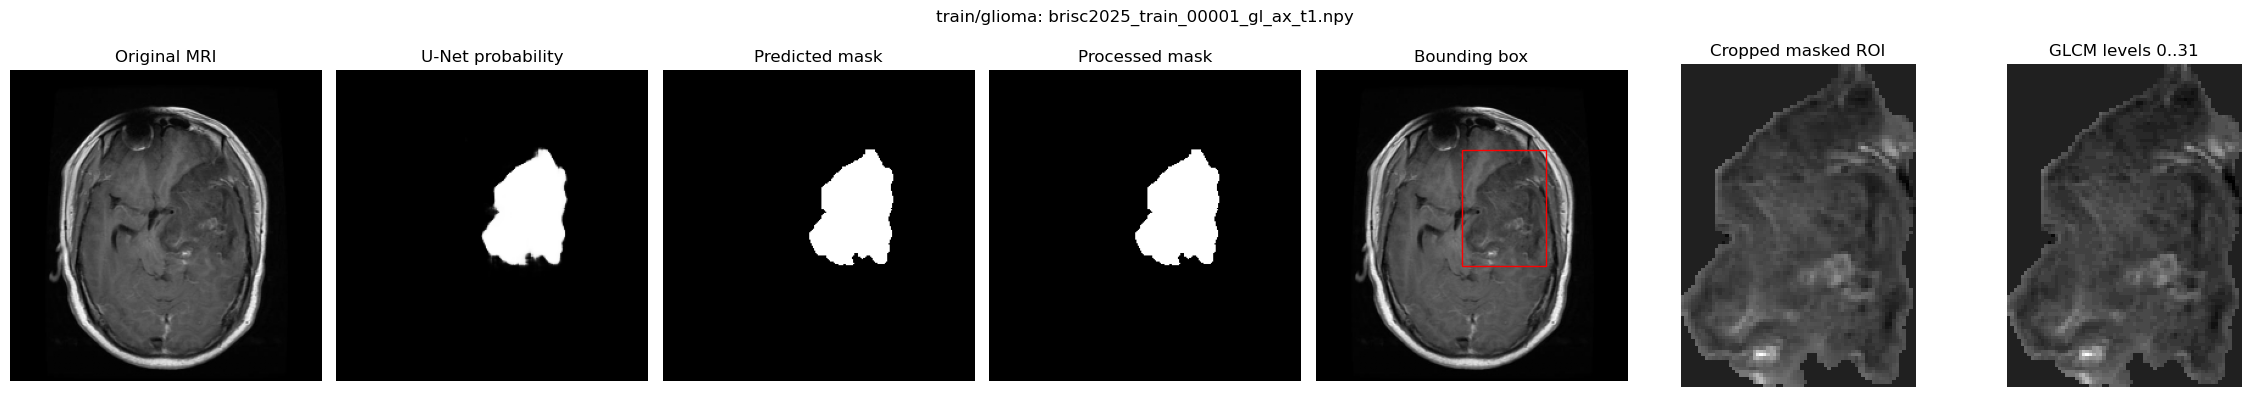

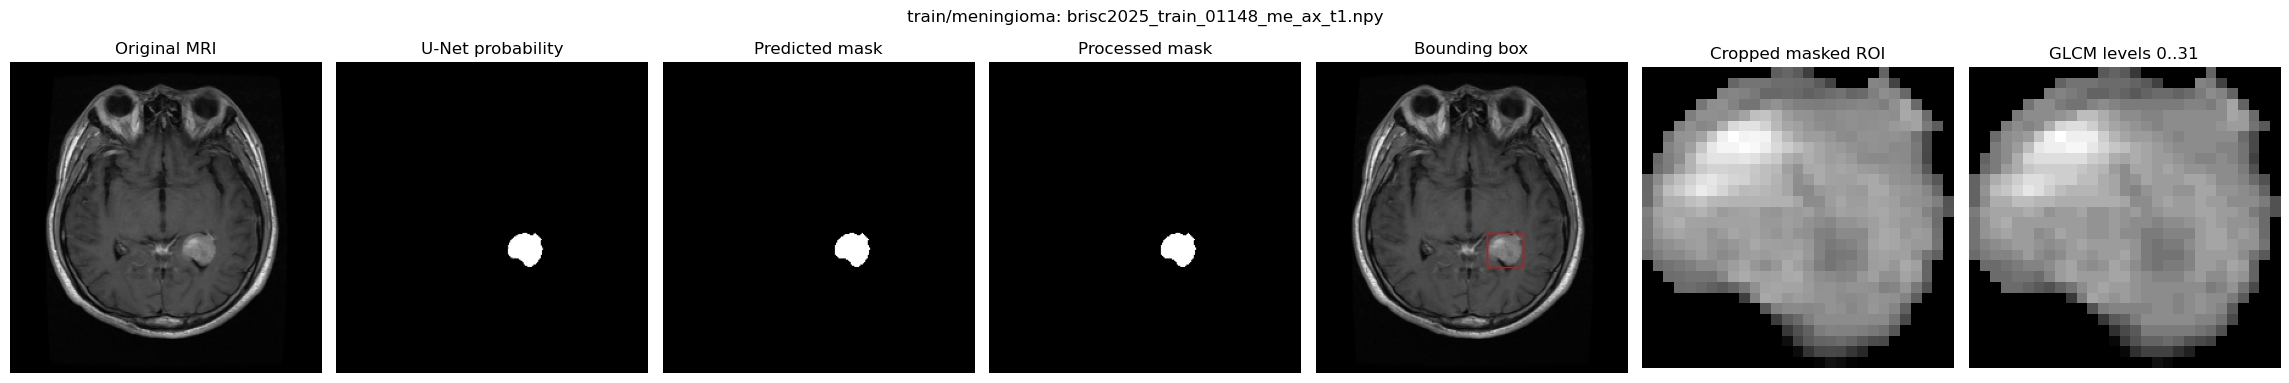

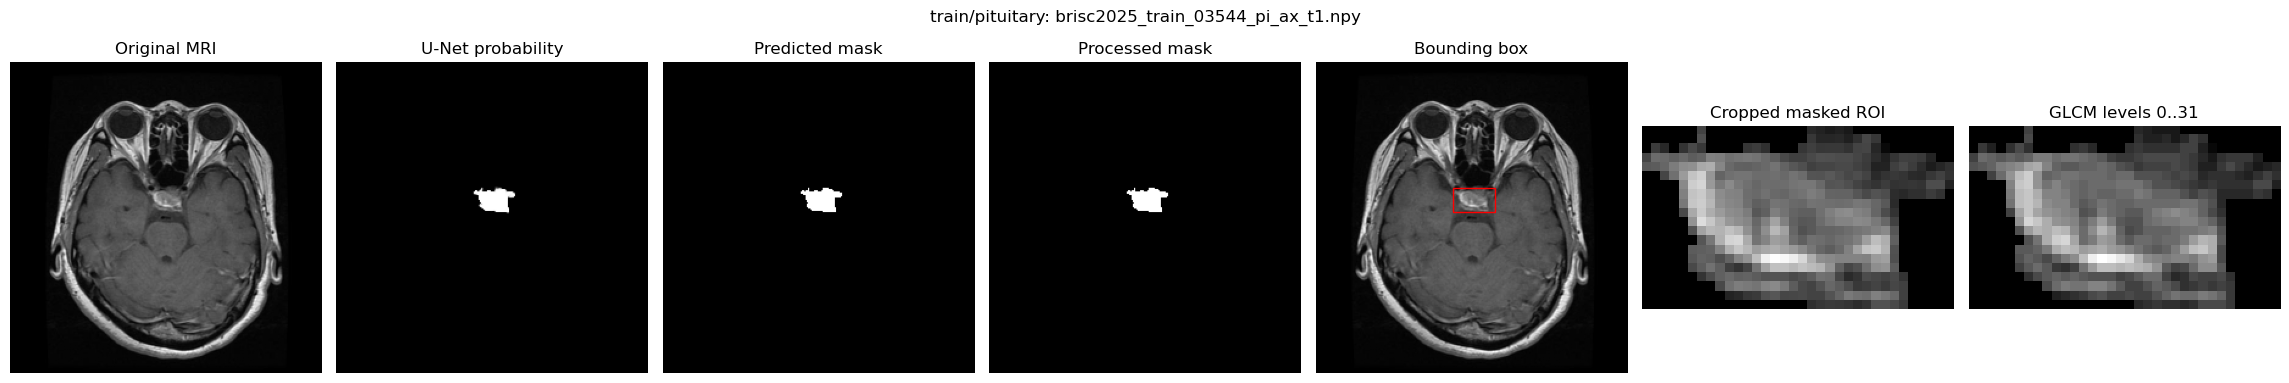

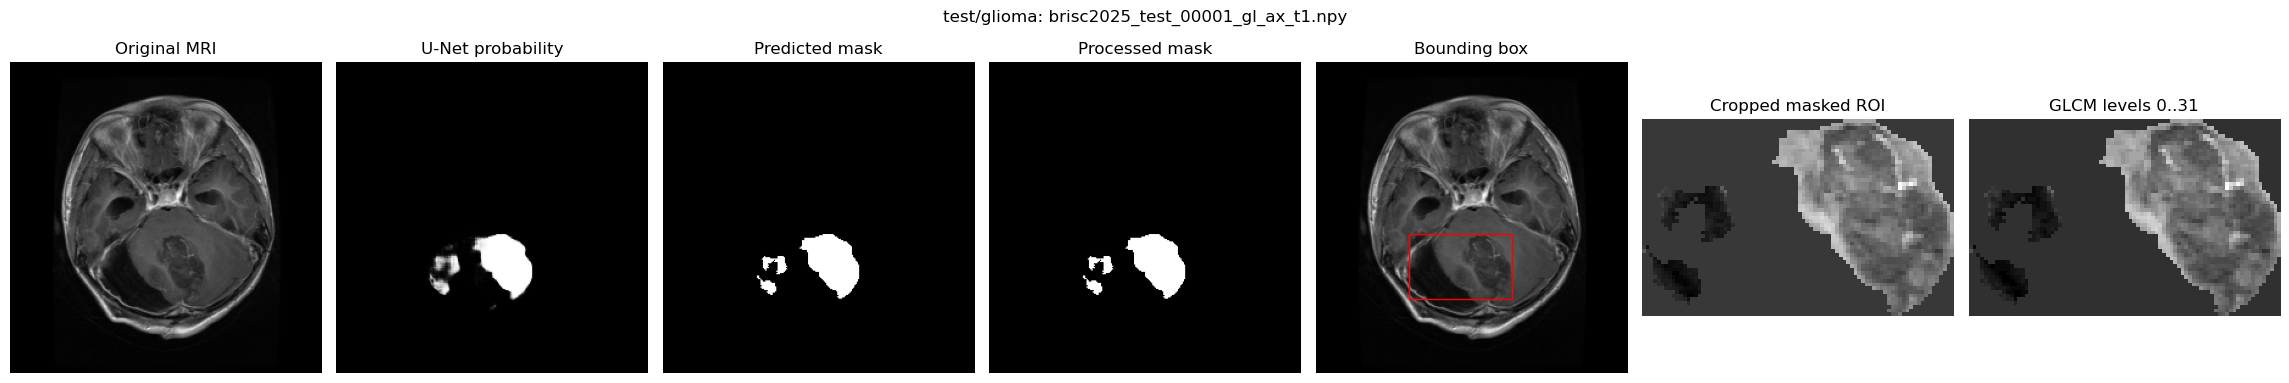

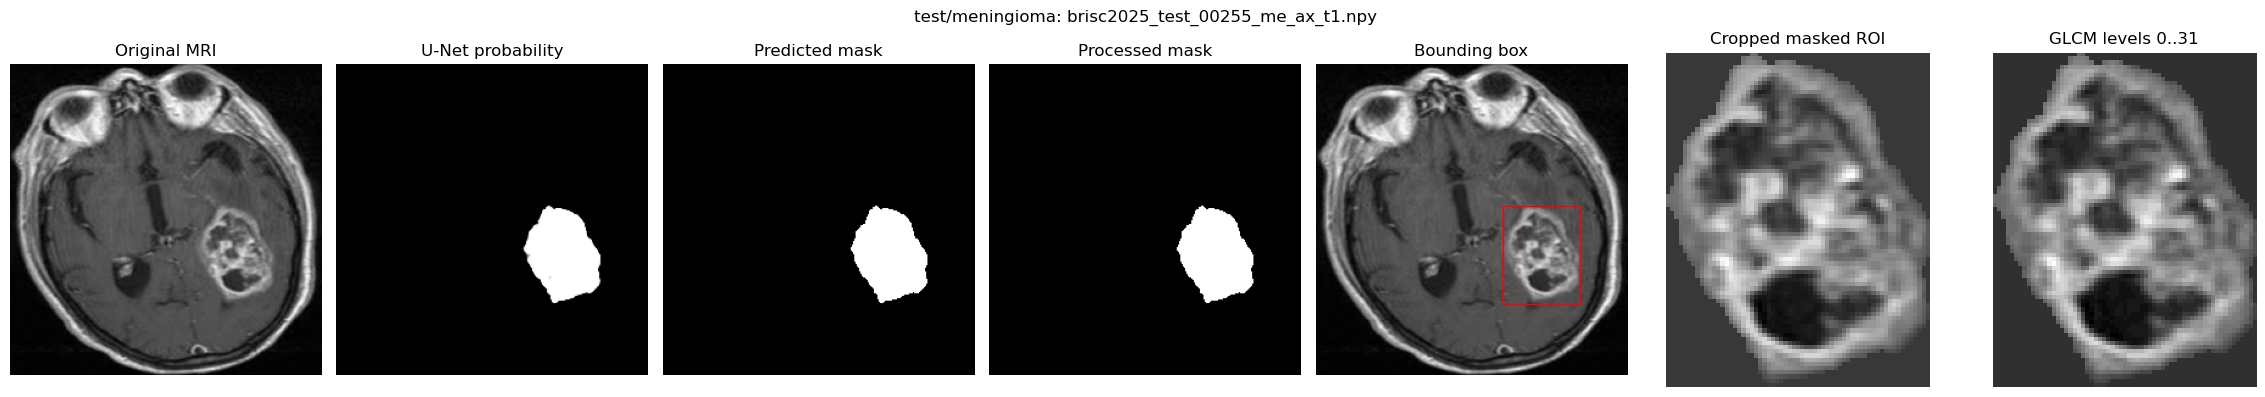

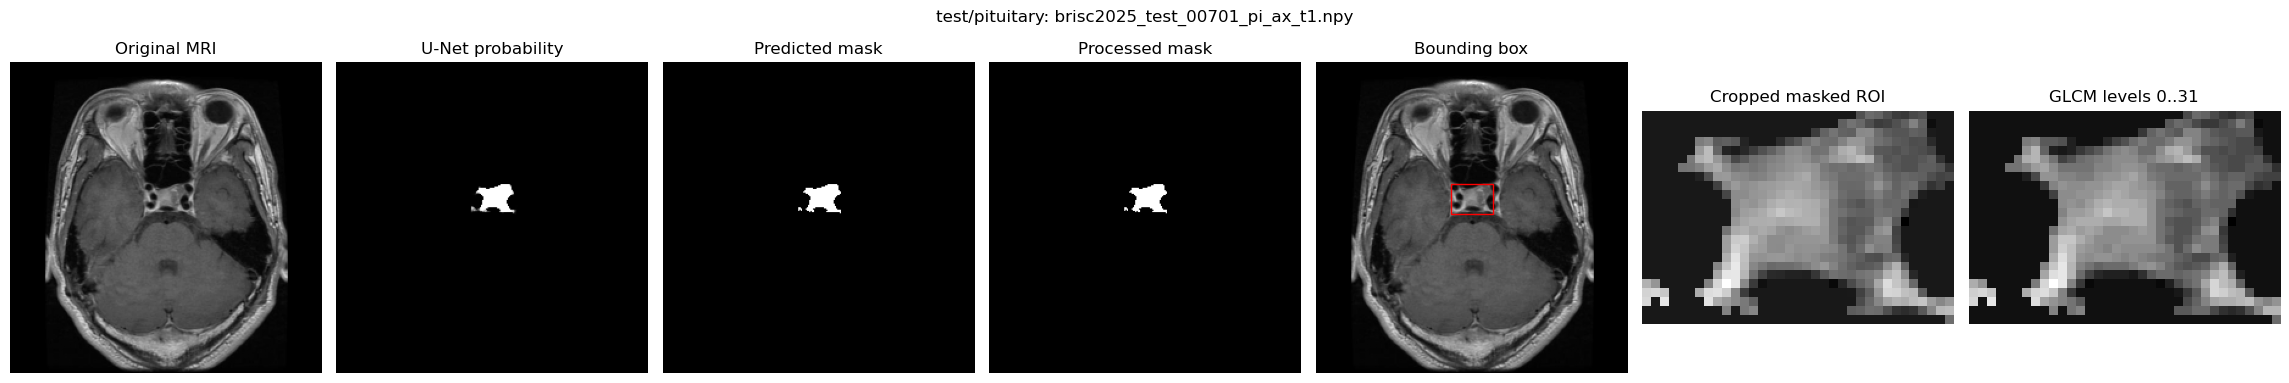

In [10]:
def quantize_crop(crop):
    if crop.ndim != 2 or crop.size == 0 or not np.isfinite(crop).all():
        raise ValueError("Invalid crop for GLCM")
    values = crop.astype(np.float64)
    low, high = float(values.min()), float(values.max())
    if high == low:
        return np.zeros(crop.shape, dtype=np.uint8)
    scaled = (values-low) / (high-low) * (GLCM_LEVELS-1)
    return np.floor(np.clip(scaled, 0, GLCM_LEVELS-1)).astype(np.uint8)


def extract_glcm(crop):
    quantized = quantize_crop(crop)
    glcm = graycomatrix(quantized, distances=GLCM_DISTANCES, angles=GLCM_ANGLES,
                       levels=GLCM_LEVELS, symmetric=True, normed=True)
    if np.any(glcm.sum(axis=(0, 1)) == 0):
        raise ValueError("No pixel pairs for at least one GLCM offset; crop too small")
    features = np.concatenate([graycoprops(glcm, prop).ravel(order="C")
                               for prop in GLCM_PROPERTIES]).astype(np.float32)
    if features.shape != (96,) or not np.isfinite(features).all():
        raise ValueError("GLCM must return exactly 96 finite values")
    return features, quantized


def process_image(path):
    image = load_mri(path)
    probability, raw_mask = predict_mask(image)
    mask = postprocess_mask(raw_mask)
    roi, crop, bbox = crop_roi(image, mask)
    features, quantized = extract_glcm(crop)
    return dict(image=image, probability=probability, raw_mask=raw_mask, mask=mask,
                roi=roi, crop=crop, bbox=bbox, features=features, quantized=quantized)


# Only a few sample results are cached; no masks or cropped images are saved.
preview_cache = {}
for split, manifest in [("train", train_manifest), ("test", test_manifest)]:
    samples = manifest.groupby("class", sort=True).head(1).head(PREVIEW_PER_SPLIT)
    for record in samples.to_dict("records"):
        try:
            result = process_image(record["path"])
            preview_cache[str(record["path"])] = result
            show_stages(result, f"{split}/{record['class']}: {record['filename']}")
        except Exception as error:
            print(f"Preview issue {record['filename']}: {type(error).__name__}: {error}")
            # Full extraction retries and records any failure in its report.


## 11. Train feature extraction


In [11]:
ISSUE_COLUMNS = ["image_name", "split", "error_type", "error_message"]


def extract_split(manifest, split, inspection_issues):
    records, issues = [], list(inspection_issues)
    started = perf_counter()
    for row in tqdm(manifest.to_dict("records"), desc=f"GLCM {split}", unit="image"):
        try:
            result = preview_cache.get(str(row["path"]))
            if result is None:
                result = process_image(row["path"])
            record = dict(zip(FEATURE_NAMES, result["features"]))
            record.update({"class": row["class"], "filename": row["filename"]})
            records.append(record)
        except Exception as error:
            issue = {"image_name": row["filename"], "split": split,
                     "error_type": type(error).__name__, "error_message": str(error)}
            issues.append(issue)
            tqdm.write(f"{split}/{row['filename']}: {issue['error_type']}: {error}")
    frame = pd.DataFrame(records, columns=FEATURE_NAMES+["class", "filename"])
    report = pd.DataFrame(issues, columns=ISSUE_COLUMNS)
    # Persist issues before later validation, including all-failed extraction.
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    report.to_csv(OUTPUT_DIR / f"{split}_processing_issues.csv", index=False)
    print(f"{split}: extracted={len(frame)}, skipped={len(report)}, elapsed={perf_counter()-started:.1f}s")
    return frame, report


train_glcm, train_issues = extract_split(train_manifest, "train", train_inspection_issues)


GLCM train:   0%|          | 0/3933 [00:00<?, ?image/s]

train/brisc2025_train_00018_gl_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
train/brisc2025_train_00027_gl_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
train/brisc2025_train_00074_gl_ax_t1.npy: ValueError: No pixel pairs for at least one GLCM offset; crop too small
train/brisc2025_train_00193_gl_ax_t1.npy: ValueError: No pixel pairs for at least one GLCM offset; crop too small
train/brisc2025_train_00206_gl_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
train/brisc2025_train_00210_gl_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
train/brisc2025_train_00211_gl_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
train/brisc2025_train_00213_gl_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
train/brisc2025_train_00223_gl_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filte

## 12. Test feature extraction


In [13]:
test_glcm, test_issues = extract_split(test_manifest, "test", test_inspection_issues)


GLCM test:   0%|          | 0/860 [00:00<?, ?image/s]

test/brisc2025_test_00005_gl_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
test/brisc2025_test_00017_gl_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
test/brisc2025_test_00054_gl_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
test/brisc2025_test_00062_gl_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
test/brisc2025_test_00140_gl_co_t1.npy: ValueError: No pixel pairs for at least one GLCM offset; crop too small
test/brisc2025_test_00156_gl_co_t1.npy: ValueError: No pixel pairs for at least one GLCM offset; crop too small
test/brisc2025_test_00372_me_ax_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
test/brisc2025_test_00910_pi_co_t1.npy: EmptyMaskError: No foreground after thresholding/component filtering
test: extracted=852, skipped=8, elapsed=1139.0s


## 13. GLCM validation
There is one row per successfully processed image. Every omitted image has an issue entry; empty masks are not represented by fabricated texture features.


In [14]:
def validate_features(frame, feature_names, manifest, issues, total, split):
    if frame.empty:
        raise ValueError(f"{split}: no feature rows; review {split}_processing_issues.csv")
    if list(frame.columns) != feature_names+["class", "filename"]:
        raise ValueError(f"{split}: invalid feature/metadata columns")
    if frame.isna().any().any() or not np.isfinite(frame[feature_names].to_numpy()).all():
        raise ValueError(f"{split}: unexpected NaN/inf")
    if frame["filename"].duplicated().any():
        raise ValueError(f"{split}: duplicate output IDs")
    labels = manifest.set_index("filename")["class"]
    expected = frame["filename"].map(labels)
    if expected.isna().any() or not np.array_equal(expected.to_numpy(), frame["class"].to_numpy()):
        raise ValueError(f"{split}: labels/IDs changed")
    if len(frame)+len(issues) != total:
        raise ValueError(f"{split}: processed/skipped count mismatch")
    if issues["image_name"].duplicated().any() or set(frame["filename"]) & set(issues["image_name"]):
        raise ValueError(f"{split}: inconsistent skip log")


for frame, manifest, issues, total, split in [
    (train_glcm, train_manifest, train_issues, train_input_count, "train"),
    (test_glcm, test_manifest, test_issues, test_input_count, "test")
]:
    validate_features(frame, FEATURE_NAMES, manifest, issues, total, split)
    assert frame[FEATURE_NAMES].shape[1] == 96 and frame.shape[1] == 98
    print(split, "rows:", len(frame), "GLCM features: 96; columns: 98; skipped:", len(issues))
assert list(train_glcm.columns) == list(test_glcm.columns)
if set(train_glcm["class"]) != set(train_manifest["class"]):
    raise ValueError("An entire training class was skipped")
if not set(test_glcm["class"]).issubset(set(train_glcm["class"])):
    raise ValueError("Extracted test class absent from training")


train rows: 3914 GLCM features: 96; columns: 98; skipped: 19
test rows: 852 GLCM features: 96; columns: 98; skipped: 8


## 14. Save GLCM CSVs


In [15]:
train_glcm.to_csv(OUTPUT_DIR / "train_glcm.csv", index=False)
test_glcm.to_csv(OUTPUT_DIR / "test_glcm.csv", index=False)
print("Saved train_glcm.csv and test_glcm.csv:", OUTPUT_DIR)


Saved train_glcm.csv and test_glcm.csv: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline


## 15. Feature scaling
StandardScaler fits only training GLCM features; the same scaler transforms test. Labels and filenames are explicitly excluded. String class labels require no label-encoder pickle.


In [16]:
X_train = train_glcm.loc[:, FEATURE_NAMES].to_numpy(dtype=np.float64)
X_test = test_glcm.loc[:, FEATURE_NAMES].to_numpy(dtype=np.float64)
if len(X_train) < N_COMPONENTS:
    raise ValueError(f"PCA-50 requires at least 50 valid train rows; got {len(X_train)}")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
if not np.isfinite(X_train_scaled).all() or not np.isfinite(X_test_scaled).all():
    raise ValueError("Non-finite scaled features")
print("Scaler fitted on train rows only:", len(X_train))


Scaler fitted on train rows only: 3914


## 16. PCA (96 → 50)
Use full SVD, exactly 50 components, no whitening. Fit train only; transform train and test with the same basis. Redundant GLCM properties can yield zero-variance components; inspect rank/variance. Do not select PCA dimensions using test accuracy.


In [17]:
if np.var(X_train_scaled, axis=0).sum() <= 0:
    raise ValueError("No training variance; PCA is not meaningful")
pca = PCA(n_components=N_COMPONENTS, svd_solver="full", whiten=False, random_state=SEED)
pca.fit(X_train_scaled)
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
PC_NAMES = [f"PC{i}" for i in range(1, N_COMPONENTS+1)]
variance_df = pd.DataFrame({"component": PC_NAMES,
                           "explained_variance_ratio": pca.explained_variance_ratio_,
                           "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)})
display(variance_df)
print("Total variance retained:", pca.explained_variance_ratio_.sum())
print("Training numerical rank:", np.linalg.matrix_rank(X_train_scaled))


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.630979,0.630979
1,PC2,0.182619,0.813598
2,PC3,0.094474,0.908072
3,PC4,0.024107,0.932179
4,PC5,0.021647,0.953826
5,PC6,0.016830,0.970656
6,PC7,0.008309,0.978965
7,PC8,0.005871,0.984836
8,PC9,0.002495,0.987331
9,PC10,0.002167,0.989497


Total variance retained: 0.9998736231166391
Training numerical rank: 84


## 17. PCA validation


In [18]:
def pca_frame(values, source):
    frame = pd.DataFrame(values, columns=PC_NAMES)
    frame["class"] = source["class"].to_numpy()
    frame["filename"] = source["filename"].to_numpy()
    return frame


train_pca = pca_frame(X_train_pca, train_glcm)
test_pca = pca_frame(X_test_pca, test_glcm)
for transformed, source in [(train_pca, train_glcm), (test_pca, test_glcm)]:
    assert transformed.shape == (len(source), 52)
    assert transformed[PC_NAMES].shape[1] == 50
    assert transformed[["class", "filename"]].equals(source[["class", "filename"]])
    if transformed.isna().any().any() or not np.isfinite(transformed[PC_NAMES].to_numpy()).all():
        raise ValueError("Invalid PCA values or metadata")
assert list(train_pca.columns) == list(test_pca.columns)
assert scaler.n_features_in_ == pca.n_features_in_ == 96
assert np.all(np.asarray(scaler.n_samples_seen_) == len(train_glcm))
assert pca.n_samples_ == len(train_glcm) and pca.n_components_ == 50
np.testing.assert_allclose(scaler.mean_, X_train.mean(axis=0))
np.testing.assert_allclose(pca.mean_, X_train_scaled.mean(axis=0), atol=1e-12)
if not np.isfinite(pca.explained_variance_ratio_).all():
    raise ValueError("Invalid explained variance")
print("Validated: train-only fit, 50 PCA features, matching columns and preserved labels/IDs")


Validated: train-only fit, 50 PCA features, matching columns and preserved labels/IDs


## 18. Save PCA CSVs and deployment artifacts
The backend needs the same extractor, ordered 96-feature vector, `scaler.pkl` and `pca.pkl`. These are joblib pickle-based objects; load with `joblib.load` in a compatible library environment. The frontend calls the backend, rather than fitting/loading Python estimators in the browser.

`pipeline_metadata.json` records the feature order, class names, segmentation/quantization settings, model SHA-256, input contract and library versions. No label encoder is needed because labels are strings. A future classifier must be trained on these new PCA features; old classifiers cannot be reused just because they accept 50 inputs.


In [19]:
def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(1024*1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


train_pca.to_csv(OUTPUT_DIR / "train_glcm_pca50.csv", index=False)
test_pca.to_csv(OUTPUT_DIR / "test_glcm_pca50.csv", index=False)
joblib.dump(scaler, OUTPUT_DIR / "scaler.pkl")
joblib.dump(pca, OUTPUT_DIR / "pca.pkl")
metadata = {
    "pipeline_version": "predicted_mask_glcm96_pca50_v1",
    "model_path": str(MODEL_PATH), "model_sha256": sha256_file(MODEL_PATH),
    "dataset_path": str(DATASET_DIR), "fit_split": "train",
    "input": {"shape": [256, 256], "dtype": "float32", "normalization": "already per-image Z-score",
              "repeat_preprocessing": False},
    "mask": {"threshold": THRESHOLD, "comparison": ">=", "connectivity": 8,
             "min_component_area": MIN_COMPONENT_AREA, "keep_all_qualifying_components": True},
    "roi": {"operation": "original MRI times binary mask", "bbox": "all foreground mask pixels; exclusive upper bounds",
            "empty_policy": "log and skip; no fabricated feature vector", "background_inside_bbox": "zero"},
    "glcm": {"distances": GLCM_DISTANCES, "angles_radians": GLCM_ANGLES, "levels": GLCM_LEVELS,
             "symmetric": True, "normed": True, "properties": GLCM_PROPERTIES,
             "quantization": "float64 crop min-max to [0,31], clip, floor, uint8; constant crop -> zeros",
             "pairs": "all pairs in rectangular masked crop including background",
             "empty_offset_policy": "log and skip"},
    "feature_names": FEATURE_NAMES, "pca_names": PC_NAMES,
    "classes": sorted(train_glcm["class"].unique().tolist()), "class_code_map": CLASS_CODE_MAP,
    "metadata_columns": ["class", "filename"],
    "scaler_file": "scaler.pkl", "pca_file": "pca.pkl", "pca_solver": "full", "whiten": False,
    "train_samples_fitted": len(train_glcm), "test_samples_transformed": len(test_glcm),
    "explained_variance_ratio": pca.explained_variance_ratio_.tolist(),
    "variance_retained": float(pca.explained_variance_ratio_.sum()),
    "versions": {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
                 "tensorflow": tf.__version__, "opencv": cv2.__version__, "scikit_image": skimage.__version__,
                 "scikit_learn": sklearn.__version__, "joblib": joblib.__version__}
}
with open(OUTPUT_DIR / "pipeline_metadata.json", "w", encoding="utf-8") as stream:
    json.dump(metadata, stream, indent=2, allow_nan=False)

# Reload fitted artifacts; do not fit or run another U-Net prediction.
loaded_scaler = joblib.load(OUTPUT_DIR / "scaler.pkl")
loaded_pca = joblib.load(OUTPUT_DIR / "pca.pkl")
np.testing.assert_allclose(loaded_pca.transform(loaded_scaler.transform(X_test[:3])), X_test_pca[:3])
for filename, expected, features in [
    ("train_glcm.csv", train_glcm, FEATURE_NAMES), ("test_glcm.csv", test_glcm, FEATURE_NAMES),
    ("train_glcm_pca50.csv", train_pca, PC_NAMES), ("test_glcm_pca50.csv", test_pca, PC_NAMES)
]:
    actual = pd.read_csv(OUTPUT_DIR / filename, dtype={"class": str, "filename": str})
    assert list(actual.columns) == list(expected.columns) and actual.shape == expected.shape
    assert actual[["class", "filename"]].equals(expected[["class", "filename"]])
    np.testing.assert_allclose(actual[features], expected[features], rtol=1e-6, atol=1e-9)
print("CSV and fitted-artifact round-trip checks passed")


CSV and fitted-artifact round-trip checks passed


### Backend reuse recipe (definition only)
Use this notebook's MRI → mask → crop → GLCM implementation and saved transformation order. Raw uploads need the project's upstream MRI preprocessing once; this helper accepts a preprocessed .npy. Empty predictions raise an error instead of a fake class result.

Do not use `BACKEND/features.py` unchanged: it currently crops with `roi > 0` and casts to uint8 before normalization. The helper below is not executed automatically. In a production backend, load the model/artifacts once at startup and reuse them.


In [20]:
def backend_pca_features(preprocessed_npy_path, artifact_dir=OUTPUT_DIR):
    with open(artifact_dir / "pipeline_metadata.json", encoding="utf-8") as stream:
        config = json.load(stream)
    if config["feature_names"] != FEATURE_NAMES or config["pca_names"] != PC_NAMES:
        raise ValueError("Backend feature order differs from fitted artifacts")
    if config["model_sha256"] != sha256_file(MODEL_PATH):
        raise ValueError("U-Net file differs from the feature-generation model")
    if (config["mask"]["threshold"] != THRESHOLD
            or config["mask"]["min_component_area"] != MIN_COMPONENT_AREA
            or config["glcm"]["distances"] != GLCM_DISTANCES
            or config["glcm"]["angles_radians"] != GLCM_ANGLES
            or config["glcm"]["levels"] != GLCM_LEVELS):
        raise ValueError("Backend extraction settings differ from fitted artifacts")
    scaler_object = joblib.load(artifact_dir / config["scaler_file"])
    pca_object = joblib.load(artifact_dir / config["pca_file"])
    result = process_image(Path(preprocessed_npy_path))
    vector = result["features"][None, :].astype(np.float64)
    transformed = pca_object.transform(scaler_object.transform(vector))
    if transformed.shape != (1, 50) or not np.isfinite(transformed).all():
        raise ValueError("Invalid backend PCA features")
    return transformed  # Feed only to a classifier trained on this new basis.


## 19. PCA visualization


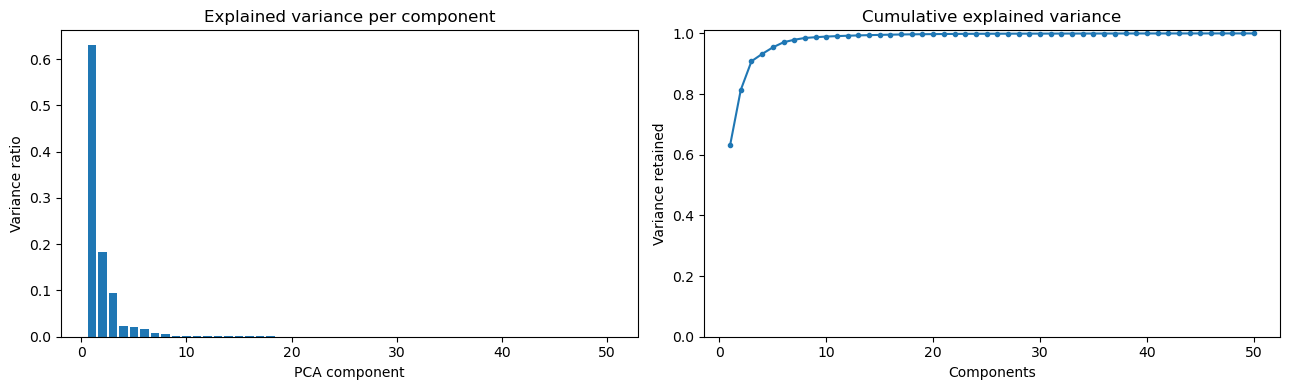

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
components = np.arange(1, 51)
axes[0].bar(components, pca.explained_variance_ratio_)
axes[0].set(title="Explained variance per component", xlabel="PCA component", ylabel="Variance ratio")
axes[1].plot(components, np.cumsum(pca.explained_variance_ratio_), marker=".")
axes[1].set(title="Cumulative explained variance", xlabel="Components", ylabel="Variance retained", ylim=(0, 1.01))
plt.tight_layout()
plt.show()
plt.close(fig)


## 20. Final pipeline summary


In [22]:
summary = pd.DataFrame([
    {"split": "train", "input_images": train_input_count, "processed": len(train_glcm), "skipped": len(train_issues)},
    {"split": "test", "input_images": test_input_count, "processed": len(test_glcm), "skipped": len(test_issues)}
])
display(summary)
print("GLCM: 96 features / 98 CSV columns; PCA: 50 features / 52 CSV columns")
print("Variance retained:", float(pca.explained_variance_ratio_.sum()))
print("Output directory:", OUTPUT_DIR)
for name in ["train_glcm.csv", "test_glcm.csv", "train_glcm_pca50.csv", "test_glcm_pca50.csv",
             "scaler.pkl", "pca.pkl", "pipeline_metadata.json", "train_processing_issues.csv", "test_processing_issues.csv"]:
    print(OUTPUT_DIR / name)
if len(train_issues) or len(test_issues):
    print("Completed with skipped images: review reports before downstream training.")
print("No masks, ROI images, U-Net weights or classifier models were saved or modified.")


,split,input_images,processed,skipped
0,train,3933,3914,19
1,test,860,852,8


GLCM: 96 features / 98 CSV columns; PCA: 50 features / 52 CSV columns
Variance retained: 0.9998736231166391
Output directory: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline\train_glcm.csv
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline\test_glcm.csv
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline\train_glcm_pca50.csv
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline\test_glcm_pca50.csv
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline\scaler.pkl
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline\pca.pkl
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline\pipeline_metadata.json
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline\train_processing_issues.csv
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Features_newPipeline\test_processin

## SVM / KNN Compatibility Report
This is a read-only source review, not a runtime test. The primary GLCM training notebooks are `Training_SVM.ipynb` and `Training_KNN_Final.ipynb`.

### SVM
**Can the new PCA-50 dataset be used? YES at schema level; NO directly with unchanged notebook paths.**

- Zero-based code cells 1 and 3 of `Training_SVM.ipynb` load `DATASET/Features(1)/pca_train.csv` and `pca_test.csv`. This new notebook writes `Features_newPipeline/train_glcm_pca50.csv` and `test_glcm_pca50.csv`. The unchanged SVM notebook therefore reads the old dataset.
- The loader reads `class` as strings, drops that label, selects numeric features and ignores nonnumeric `filename`. It dynamically accepts PC1–PC50. No additional scaler/PCA fit is performed.
- Required future changes: update its input paths and train a new classifier using this new PCA basis. Existing `final_svm.pkl` is not interchangeable even if its input dimension is 50. No classifier changes/training were made here.

### KNN
**Can the new PCA-50 dataset be used? YES at schema level; NO end-to-end in the unchanged notebook.**

- Zero-based code cell 1 in `Training_KNN_Final.ipynb` configures the same older `Features(1)` CSV paths.
- Cell 3 dynamically selects `PC` columns, reads `class`, ignores `filename`, and handles 50 components without dimension changes. There is no additional scaler/PCA fit. Unwhitened PC scores weight high-variance components more in KNN distances; this matches the existing direct-PCA input approach.
- **The inspected notebook has no `pd.read_csv` call initializing `train_df`/`test_df` before cell 3 uses them.** In a fresh kernel these variables are missing; in a reused kernel they could contain stale data.
- Required future changes: explicitly load the new CSV files and update paths. Use a classifier trained on the new PCA basis. No such modifications were made.

### Leakage, related variants and deployment
- This notebook fits StandardScaler/PCA on train only and transforms test. No ground-truth masks generate features. Local U-Net provenance and patient overlap cannot be proved from source/filenames alone.
- Both GLCM classifier notebooks cross-validate classifiers on precomputed PCA features. Fitting scaler/PCA on the entire training set before those folds lets validation-fold information influence preprocessing. Strict CV would refit preprocessing inside each training fold. This is a CV limitation, not fitting on the held-out test set.
- DWT variants (`Training_SVM_DWT.ipynb`, `Training_KNN_DWT.ipynb`) point to `DATASET/Features_DWT/pca_fusion_train.csv` and `pca_fusion_test.csv`. Their feature semantics and trained models differ from GLCM. The SVM DWT notebook also contains a PCA component sweep using `X_fusion_train_scaled`/`X_fusion_test_scaled` and test accuracy; the new CSVs do not supply those variables. Selecting dimensions from that test sweep would leak test information. Those notebooks were not changed.
- `BACKEND/features.py` still uses the old positive-intensity crop and pre-normalization uint8 conversion. Backend integration must use this new extractor with its newly fitted scaler/PCA and a matching future classifier. No backend code was modified.

**Can I proceed with PCA-reduced 50-feature data for KNN and SVM without modifying the existing training code? NO, not end-to-end as currently written.** Both support the feature format, but the paths and KNN's missing loading step prevent direct use. Strict fold-independent preprocessing also requires a future training workflow change. Issues are reported only; SVM/KNN loading, preprocessing, hyperparameters and model files were not edited.
